<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%B0_%D0%B7%D0%BD%D0%B0%D0%BD%D0%B8%D0%B9_%7C_Functional_API_%D0%BD%D0%B5%D0%BB%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D1%81%D1%82%D1%80%D1%83%D0%BA%D1%82%D1%83%D1%80%D0%B0_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8_%D0%9D%D0%A1_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Разбор разных структур НС

##Структура модели сети

Библиотека **Keras** располагает двумя способами создания моделей нейронной сети:

 - Способ создания линейной (последовательной) структуры сети - **Sequential( )**
 - Способ создания нелинейной структуры сети - **Functional API**.


В данном теоретическом материале рассматривается последний, однако, для закрепления материала сначала приведём пример построения линейной модели сети.

Выполним импорт необходимых библиотек и модулей:

In [2]:
# Классы для конструирования модели нейронной сети
from tensorflow.keras.models import Sequential, Model

# Все слои Keras
from tensorflow.keras.layers import *

# Модуль функций-утилит Keras
from tensorflow.keras import utils

##Модель Sequential

Далее создаётся архитектура линейной модели нейросети:

  - Первой строкой объявляется необходимый класс модели - в данном случае это **Sequential( )**;
  - Все последующие строки, кроме последней - последовательное добавление слоёв сети функцией **add( )**;
  - Последняя строка - компиляция модели функцией **compile( )**.

In [3]:
sequential_model = Sequential()                                     # Создание последовательной модели нейросети
sequential_model.add(Dense(200, input_dim=10, activation="relu"))   # Первый полносвязный слой
sequential_model.add(Dropout(0.25))                                 # Слой регуляризации Dropout
sequential_model.add(BatchNormalization())                          # Слой пакетной нормализации
sequential_model.add(Dense(2, activation='sigmoid'))                # Выходной полносвязный слой

sequential_model.compile(optimizer="adam",                          # Объединение слоёв архитектуры в единую модель
                  loss='categorical_crossentropy',                  # C соответствующими параметрами оптимизатора, ошибки сети и типа метрики
                  metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Структура сети всегда понятна лучше, если отобразить схему модели.

Это можно сделать с помощью функции **plot_model( )** модуля **utils**:

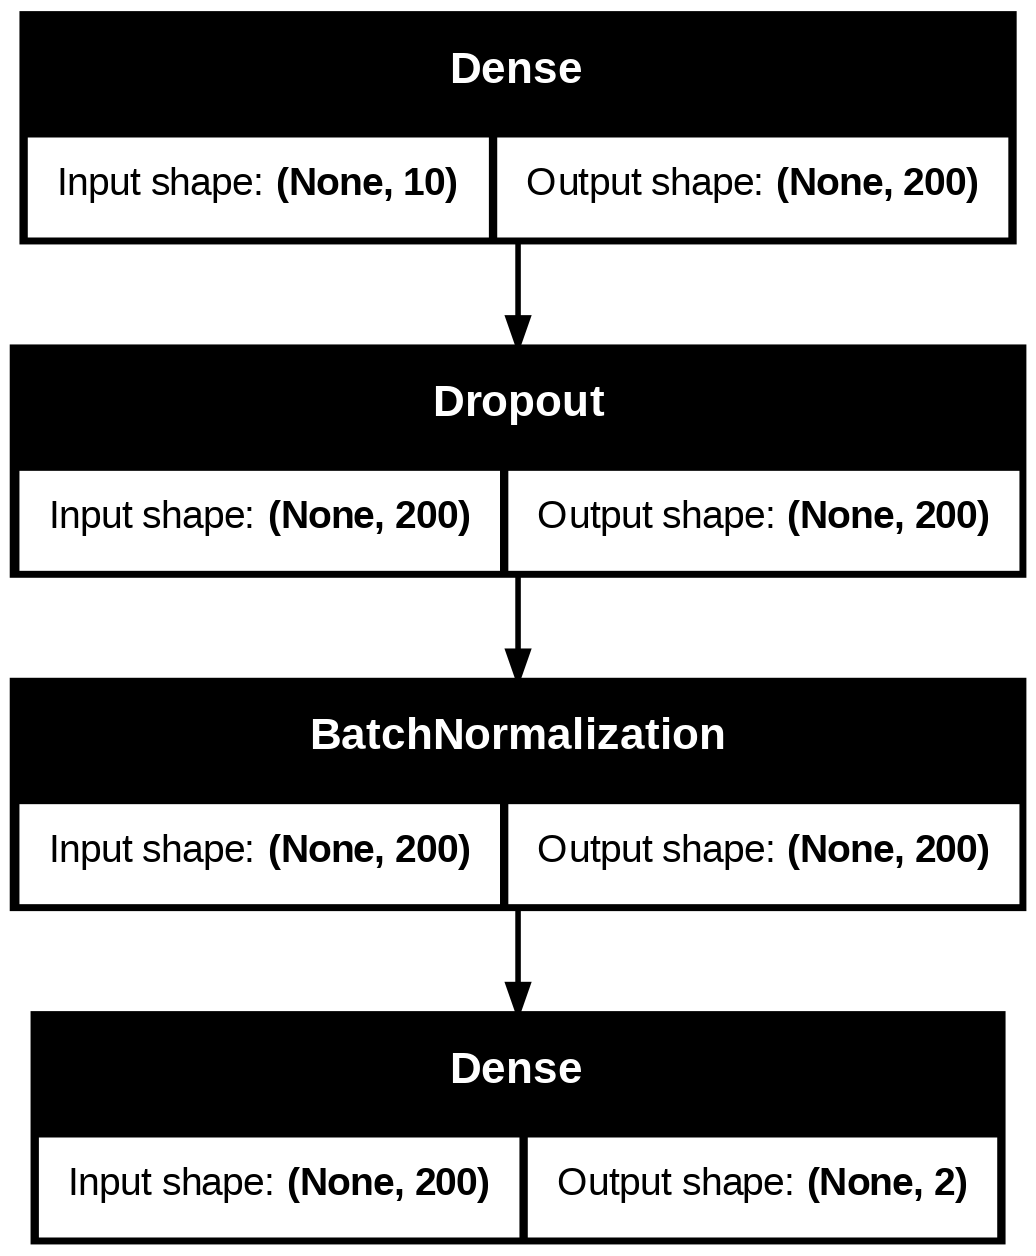

In [4]:
utils.plot_model(sequential_model, show_shapes=True) # Первый параметр - модель; show_shapes=True - показать размерности входных и выходных тензоров

Линейная структура Sequential подразумевает один входной канал для обучающих данных. Будучи поданными во входной слой линейной модели данные проходят от слоя к слою последовательно, пока не достигают выхода сети. Таким образом, создавая линейную архитектуру сети разработчик имеет возможность работать только с одним типом данных за один запуск обучения. И, что логично вытекает из этого же факта, разработчик также не имеет возможности обучить сеть мультизадачности, так как подобная модель не подразумевает объединения данных и более одного входного тензора данных.


Для некоторых задач разработчику просто необходимо работать с разными типами данных (текст, изображения, аудио и т.д.) или просто несколькими каналами слоёв в рамках одной нейронной сети. Примеры задач варьируются: иногда требуется, чтобы предсказание сети зависело от обучения сразу на нескольких входных наборах, а иногда наоборот - вход сети один, но слоёв с выходами уже несколько (как в модели **U-Net**). Тогда разработчик прибегает к использованию модели с нелинейной структурой. В Keras такие модели носят название **Functional APIs**.



##Functional API

Далее рассмотрим создание **Functional API** на практическом примере. Условимся, что нелинейная модель собирается с целью подачи в сеть сразу двух типов данных - изображений и текста. Так, одна ветвь модели может содержать свёрточные слои, а другая - слой Embedding. Создание нелинейной структуры сети имеет свои особенности:

  - Для каждой ветви модели необходимо создать свой входной слой **Input( )**;
  - Объединение ветвей в один блок также обязательный шаг, осуществляемый при помощи методов **concatenate( )**, **add( )** или **multiply( )**.
  - Сам класс модели - в данном случае это **Model( )** - создаётся на последнем шаге создания архитектуры, а не в начале, как с Sequential( ).

Создадим модель Functional API для вышеупомянутой задачи:

  - conv_input - входной слой для блока изображений (shape - размер входного изображения, name - имя для слоя);
  - x1 - первый и каждый последующий слои блока обработки изображений (связь слоя со входом, а потом с каждым следующим слоем указываем отдельно в скобках в конце каждой строки);
  - emb_input - входной слой для текстового блока (параметры аналогичны conv_input);
  - x2 - первый и каждый последующий слои текстового блока(и так же связь слоя со входом блока, а потом с каждым следующим слоем - отдельно в скобках в конце каждой строки);
  - x - объединение слоёв каждого из блоков методом **concatenate()**;
  - out - выходной слой, который обработает обобщённые по двум блокам данные;
  - model - объявление класса **Model( )** для создания нелинейной модели, в параметрах которой объединены два отдельных входа и общий выход сети.

In [5]:
conv_input = Input(shape=(128,128,3), name = 'conv_input')

x1 = Conv2D(32, (3,3), padding='valid', activation = 'relu', name='Conv2D') (conv_input)
x1 = Flatten(name='Flatten_1') (x1)
x1 = Dense(128, activation='relu', name='Dense_1') (x1)

emb_input = Input(shape=(1000,), name='emb_input')
x2 = Embedding(1000, 100, input_length=10, name='Embedding') (emb_input)
x2 = Flatten(name = 'Flatten_2') (x2)
x2 = Dense(128, name = 'Dense_2') (x2)

x = concatenate([x1, x2])

out = Dense(10, activation = 'softmax', name = 'output') (x)

model = Model ([conv_input, emb_input], out)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Всё те же методом **plot_model( )** модуля **utils** отобразим схему нелинейной модели сети:

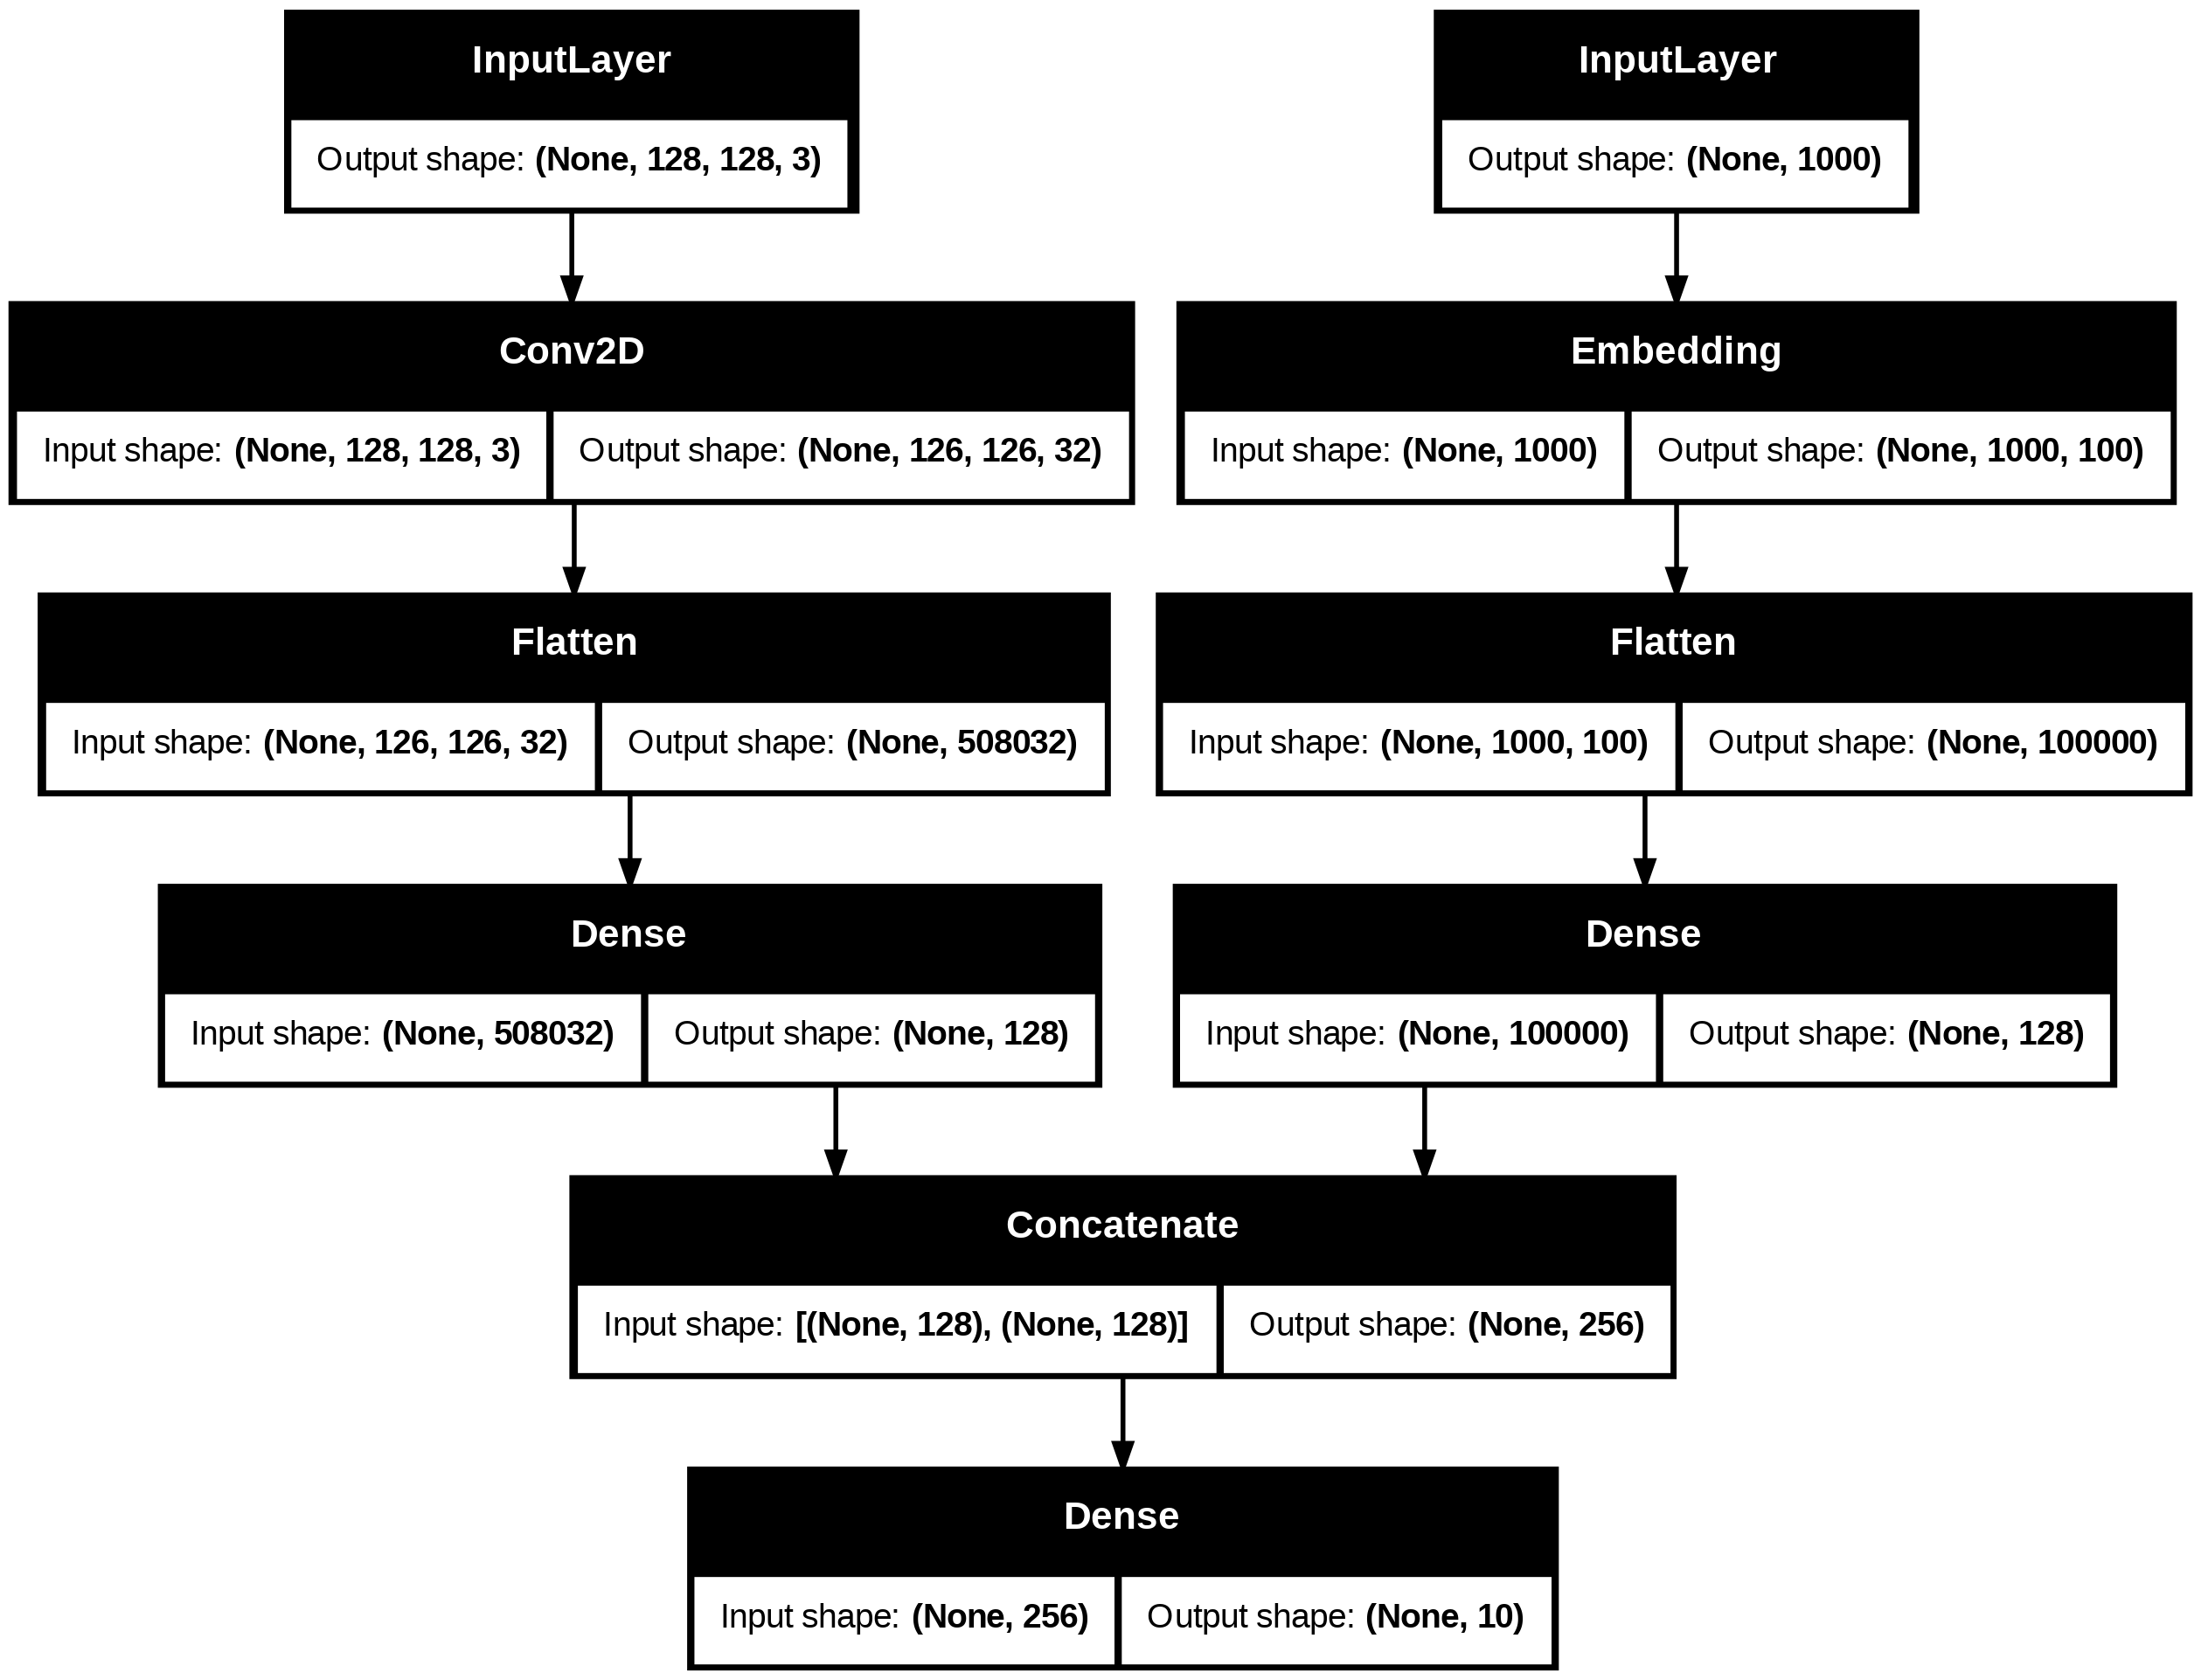

In [6]:
utils.plot_model(model, show_shapes=True)

Важно помнить: операция объединения слоёв может быть выполнена только тогда, когда параметры каждого слоя образуют размерности, соответствующие требованиям объединения матриц.

##ResNet-блок

**Residual Neural Network**,  или **ResNet** -  модель сети, основанная на принципе остаточного обучения. Появление модели ResNet способствовало очень значительному прогрессу в области машинного зрения. Особенность данной сети - функционирование её слоёв: модель выстраивает связи между некоторыми слоями подражая принципу связей головного мозга. Схема модели ResNet поначалу кажется линейной, но слои модели имеют несколько выходов, где один из них - выход, образующий срез от одного слоя к другому в обход последовательной структуры сети. Таким образом структура модели тоже становится нелинейной:

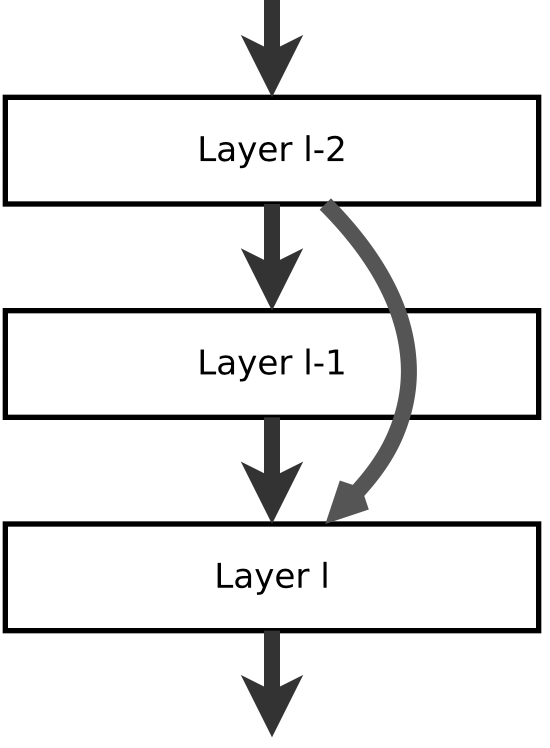

Необязательно использовать схему блока, представленную выше, как структуру для всей сети. ResNet-блок часто используется как составляющий элемент в многих сложных архитектурах.

Реализуем resnet-блок с помощью Functional API:

In [7]:
def res_block(layer, count):
  x = Conv2D(32, (3,3), padding='same') (layer)
  for _ in range(count):
    x = Conv2D(32, (3,3), padding='same') (x)
  out = add([layer, x])
  return out


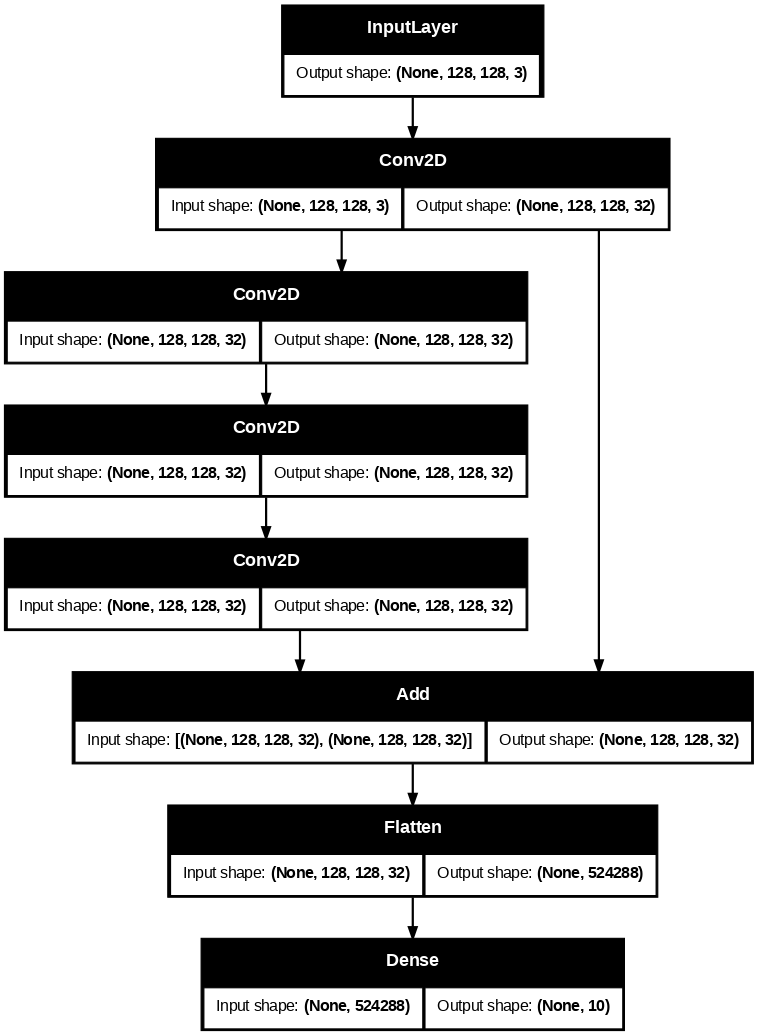

In [8]:
inp = Input(shape=(128,128,3))
layer = Conv2D(32, (3,3), padding='same') (inp)
res = res_block(layer, 2)
out = Flatten() (res)
out = Dense(10, activation='softmax') (out)

model = Model(inp, out)
utils.plot_model(model, show_shapes=True, dpi = 80)